In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = []

for i in range(600):

    acute = np.random.uniform(500, 1200)
    chronic = np.random.uniform(600, 1000)

    acwr = acute / chronic

    fatigue = np.random.randint(1, 10)
    sleep = np.random.uniform(4, 9)

    if acwr > 1.25:
        injury = 1 if np.random.rand() > 0.2 else 0
    elif acwr < 0.95:
        injury = 0 if np.random.rand() > 0.2 else 1
    else:
        injury = 1 if (fatigue > 6 and sleep < 6 and np.random.rand() > 0.3) else 0

    rows.append([acute, chronic, acwr, fatigue, sleep, injury])

df = pd.DataFrame(rows, columns=[
    "acute_load", "chronic_load", "acwr",
    "fatigue_score", "sleep_hours", "injury"
])

df.to_csv("final_injury_data.csv", index=False)

print(len(df))

600


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop("injury", axis=1)
y = df["injury"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(accuracy_score(y_test, pred))

0.825


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X = df.drop("injury", axis=1)
y = df["injury"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

for model, acc in results.items():
    print(model, ":", acc)

Logistic Regression : 0.7916666666666666
Decision Tree : 0.8
Random Forest : 0.825
SVM : 0.825
KNN : 0.8


In [5]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: Random Forest


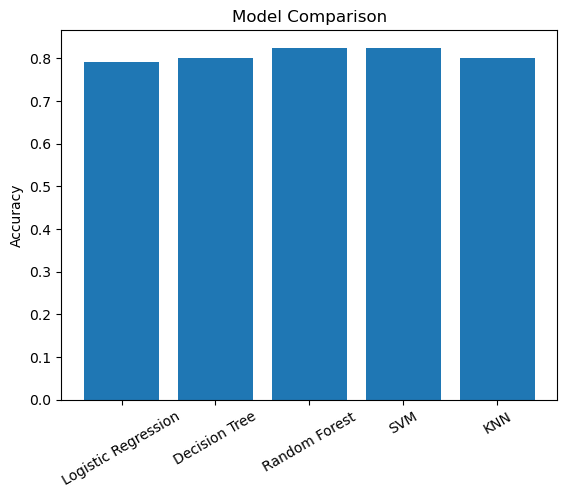

In [6]:
import matplotlib.pyplot as plt

names = list(results.keys())
values = list(results.values())

plt.bar(names, values)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

In [7]:
final_model = RandomForestClassifier(n_estimators=200, max_depth=5)
final_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200)

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 5, 6, 8],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [9]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.825
[[77  9]
 [12 22]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88        86
           1       0.71      0.65      0.68        34

    accuracy                           0.82       120
   macro avg       0.79      0.77      0.78       120
weighted avg       0.82      0.82      0.82       120



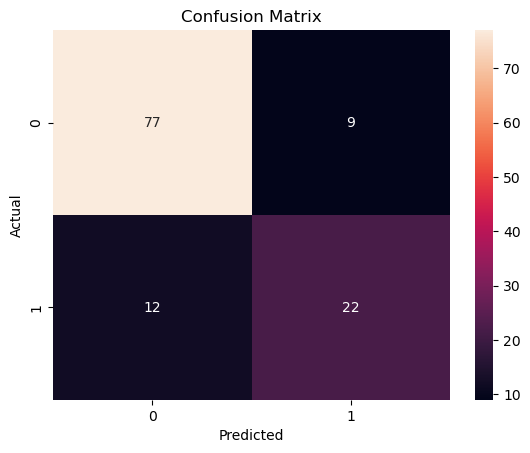

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

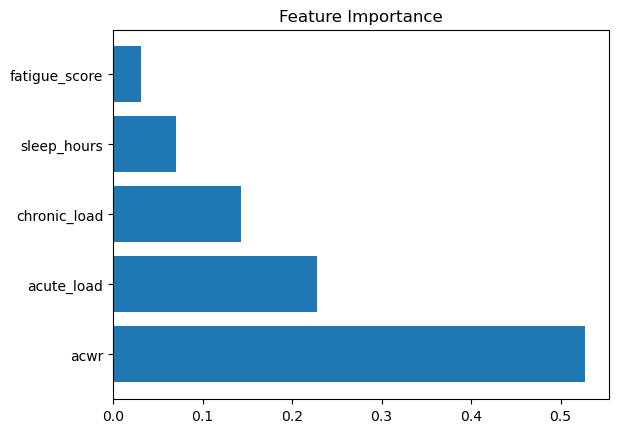

In [12]:
import pandas as pd

importance = best_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Feature Importance")
plt.show()

In [1]:
sample = [[900, 700, 1.28, 8, 5.5]]

result = best_model.predict(sample)

print("Injury Risk:", "HIGH ⚠️" if result[0] == 1 else "LOW ✅")

NameError: name 'best_model' is not defined

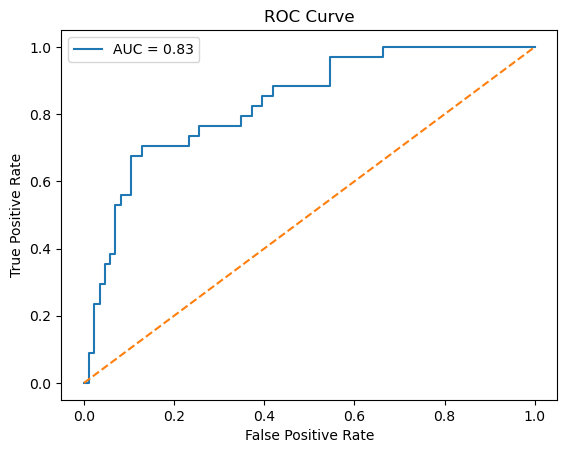

In [14]:
from sklearn.metrics import roc_curve, auc

probs = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.83333333 0.85833333 0.825      0.84166667 0.85833333]
Average accuracy: 0.8433333333333334


In [16]:
import joblib

joblib.dump(best_model, "injury_model.pkl")

['injury_model.pkl']

In [17]:
model = joblib.load("injury_model.pkl")

In [18]:
acute = float(input("Enter acute load: "))
chronic = float(input("Enter chronic load: "))
acwr = acute / chronic
fatigue = int(input("Enter fatigue (1-10): "))
sleep = float(input("Enter sleep hours: "))

sample = [[acute, chronic, acwr, fatigue, sleep]]

result = model.predict(sample)

print("HIGH RISK ⚠️" if result[0] == 1 else "LOW RISK ✅")

HIGH RISK ⚠️


c:\Users\Aryan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [19]:
df.to_csv("final_dataset.csv", index=False)

In [20]:
import joblib
joblib.dump(best_model, "injury_model.pkl")

['injury_model.pkl']